# What are the most in demand skills for the top 3 most popular data roles

##### Methodology
1. Clean-up skills column 
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings

In [64]:
#importing libraries
import ast 
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [65]:
df_US = df[df['job_country']== "United States"]

In [66]:
df_skills= df_US.explode('job_skills')

In [67]:
df_skills_count= df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count= df_skills_count.reset_index(name= 'skills_count')

df_skills_count= df_skills_count.sort_values('skills_count', ascending= False, )

df_skills_count

,job_skills,job_title_short,skills_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [80]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])

len(job_titles)

3

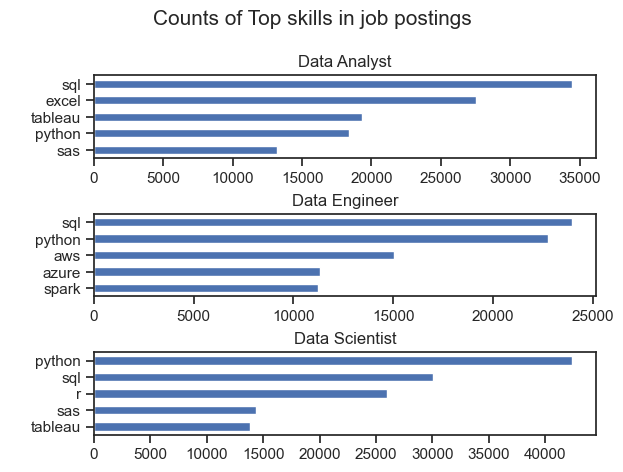

In [79]:
fig, ax= plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_plot= df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh', x= 'job_skills', y= 'skills_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel(' ')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top skills in job postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()


# Skills percentage

In [78]:
df_job_title_count= df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [77]:
df_skills_perc= pd.merge(df_skills_count, df_job_title_count,how="left" ,on= "job_title_short")

In [83]:
df_skills_perc['skills_perecnt']=100* df_skills_perc['skills_count']/df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skills_count,jobs_total,skills_perecnt
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


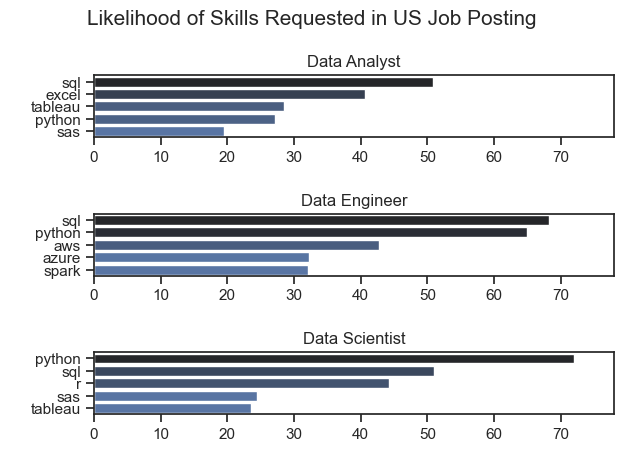

In [92]:
fig, ax= plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot= df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5)
    sns.barplot(data=df_plot, x= 'skills_perecnt',y= 'job_skills', ax=ax[i], hue='skills_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_xlim(0, 78)
    ax[i].set_ylabel(' ')
    ax[i].set_xlabel(' ')
    ax[i].legend().set_visible(False)

fig.suptitle('Likelihood of Skills Requested in US Job Posting', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()